# Assignment 3

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model](https://open.spotify.com/track/4R3AU2pjv8ge2siX1fVbZs?si=b2712f32da0e4358) or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [2]:
# Load the libraries as required.
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [4]:
fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [5]:
print(fires_dt.shape)

(517, 13)


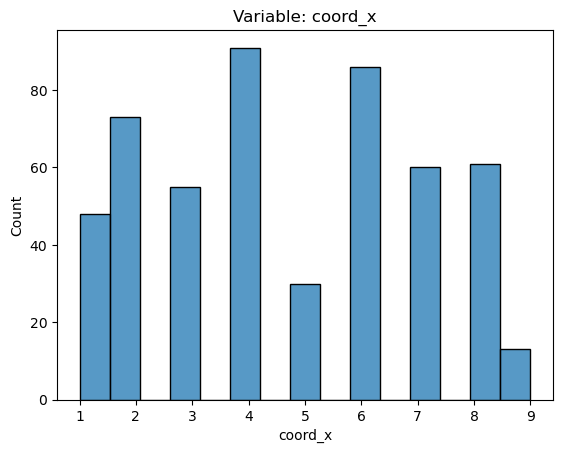

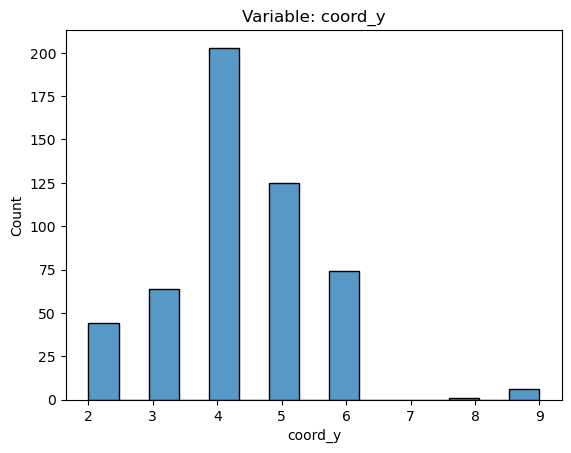

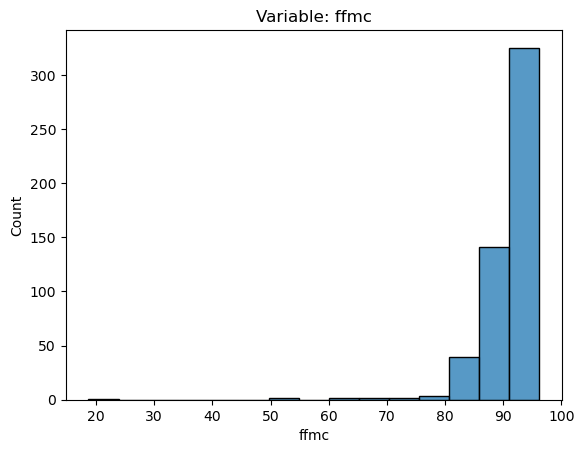

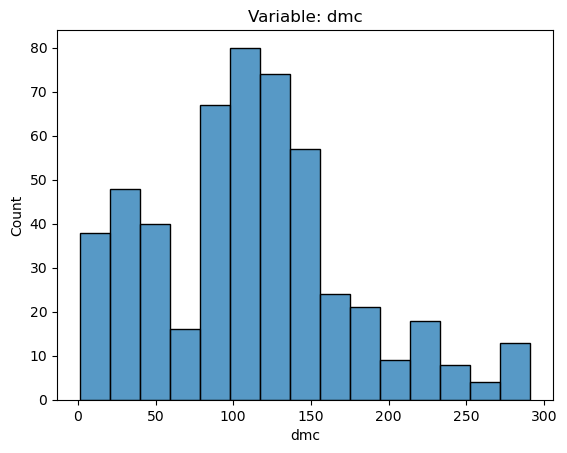

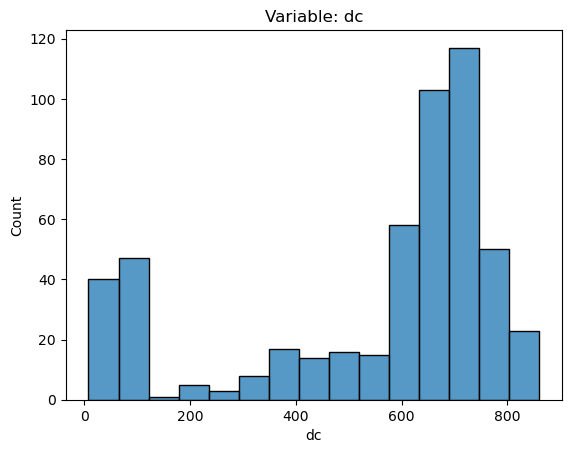

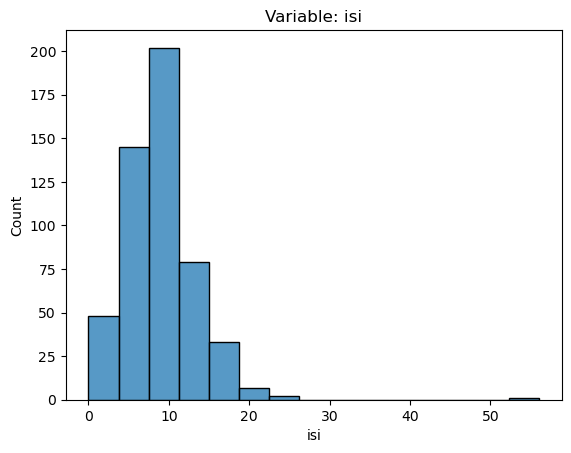

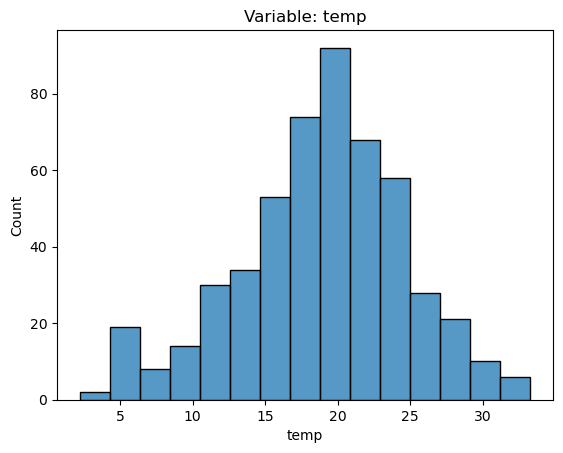

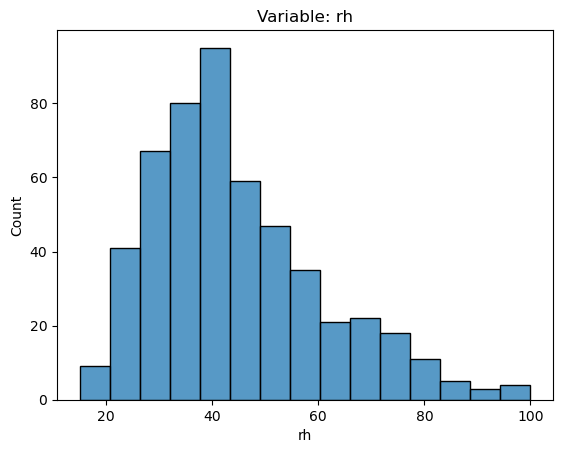

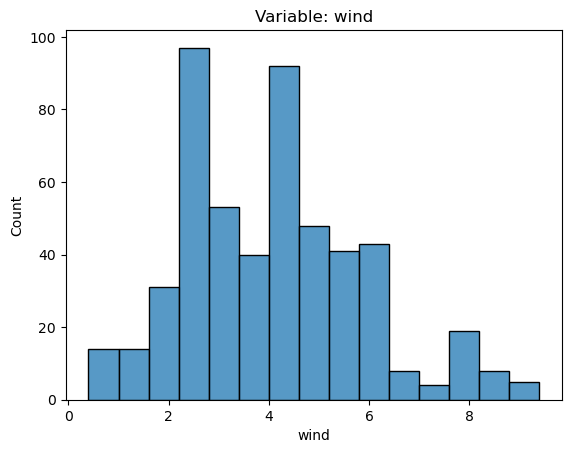

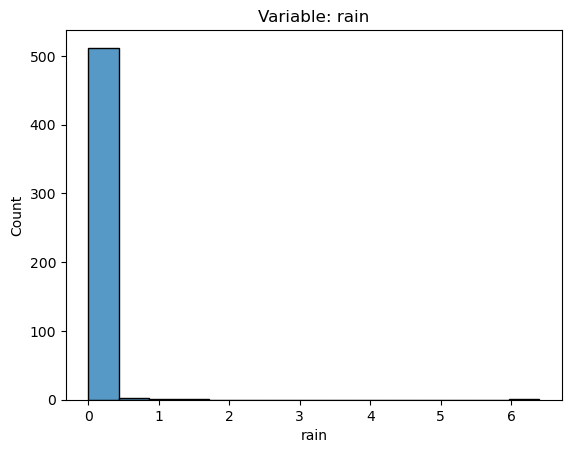

In [6]:
# as we will note later, there needs to be a scaler
# in case we need to use robust scaler, let's check the distribution of these variables
import matplotlib.pyplot as plt
import seaborn as sns
cols = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']

for i in cols:
    sns.histplot(data=fires_dt, x=i, bins=15)
    plt.title('Variable: ' + i)
    plt.show()

We notice a couple of variables have some outliers. In particular, these are ffmc, isi, and rain.

# Get X and Y

Create the features data frame and target data.

In [7]:
# create x and y dataset
X = fires_dt.drop(columns=['area'])
Y = fires_dt[['area']]

print(X.head())
print(Y.head())

   coord_x  coord_y month  day  ffmc   dmc     dc  isi  temp  rh  wind  rain
0        7        5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0
1        7        4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0
2        7        4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0
3        8        6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2
4        8        6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0
   area
0   0.0
1   0.0
2   0.0
3   0.0
4   0.0


In [8]:
# split the data 70-30
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, 
      Y_train.shape, Y_test.shape)

(361, 12) (156, 12) (361, 1) (156, 1)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


In [9]:
# overall, let's collect the variables that are continuous and categorical
num_cols = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
cat_cols = ['month', 'day']

### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [37]:
# import some more packages
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, StandardScaler

In [36]:
# numerical pipeline with robust scaler and categorical
# create the column transformer
preproc1 = ColumnTransformer([
    ('numerical', RobustScaler(), num_cols),
    ('categorical', OneHotEncoder(handle_unknown='infrequent_if_exist'), cat_cols)
])

# confirm set up
preproc1

ColumnTransformer(transformers=[('numerical', RobustScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                  'isi', 'temp', 'rh', 'wind', 'rain']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                 ['month', 'day'])])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [12]:
# to decide which transformations we want to use, I read through some of the pre-processing documentation
# https://scikit-learn.org/dev/auto_examples/preprocessing/plot_map_data_to_normal.html#sphx-glr-auto-examples-preprocessing-plot-map-data-to-normal-py
# this link provides some images we can use

# we will try using a quantile transformation on these variables with output set to normal distribution
from sklearn.preprocessing import QuantileTransformer

In [38]:
# variables for the pipelines
num_reg_cols = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'temp', 'dc', 'wind']
num_t_cols = [ 'rain', 'rh', 'isi']
cat_cols = ['month', 'day']

# set the column transformer
preproc2 = ColumnTransformer([
    ('num_scaled', StandardScaler(), num_reg_cols),
    ('num_trans', QuantileTransformer(output_distribution='normal'), num_t_cols),
    ('cat_trans', OneHotEncoder(handle_unknown="infrequent_if_exist", drop="if_binary"), cat_cols)
])

# view set up
preproc2

ColumnTransformer(transformers=[('num_scaled', StandardScaler(),
                                 ['coord_x', 'coord_y', 'ffmc', 'dmc', 'temp',
                                  'dc', 'wind']),
                                ('num_trans',
                                 QuantileTransformer(output_distribution='normal'),
                                 ['rain', 'rh', 'isi']),
                                ('cat_trans',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='infrequent_if_exist'),
                                 ['month', 'day'])])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [157]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import BaggingRegressor

#### Pipeline A

In [158]:
# Pipeline A = preproc1 + baseline

# preproc1 with Lasso
pipe_a_preproc1 = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Lasso())
])

pipe_a_preproc1

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', RobustScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', Lasso())])

#### Pipeline B

In [159]:
# Pipeline B = preproc2 + baseline

# with preproc 2
pipe_b_preproc2 = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Lasso())
])

pipe_b_preproc2

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_scaled',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'temp', 'dc',
                                                   'wind']),
                                                 ('num_trans',
                                                  QuantileTransformer(output_distribution='normal'),
                                                  ['rain', 'rh', 'isi']),
                                                 ('cat_trans',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', Lasso())])

#### Pipeline C

In [42]:
# Pipeline C = preproc1 + advanced model

# preproc1 with bgging
pipe_c_preproc1 = Pipeline([
    ('preprocessing', preproc1), 
    ('regressor', BaggingRegressor())
])

pipe_c_preproc1

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical', RobustScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', BaggingRegressor())])

#### Pipeline D

In [43]:
# Pipeline D = preproc2 + advanced model
pipe_d_preproc2 = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', BaggingRegressor())
])

pipe_d_preproc2

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_scaled',
                                                  StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'temp', 'dc',
                                                   'wind']),
                                                 ('num_trans',
                                                  QuantileTransformer(output_distribution='normal'),
                                                  ['rain', 'rh', 'isi']),
                                                 ('cat_trans',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='infrequent_if_exist'),
                                                  ['month', 'day'])])),
                ('regressor', BaggingRegressor())])

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [99]:
from sklearn.model_selection import GridSearchCV

scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error']

In [161]:
#hyper parameter values
hyper_lin = {
    "regressor__fit_intercept": [True, False],
    "regressor__tol": [0.00001, 0.0001, 0.001]               
}

hyper_bag = {
    'regressor__n_estimators': [100, 150, 200, 250, 300],
    'regressor__max_samples': [0.1, 0.5, 1.0]
}

#### Model: Pipeline A

In [162]:
# pipeline a, preproc1 Lasso
grid_pipe_a = GridSearchCV(
    estimator=pipe_a_preproc1,
    param_grid = hyper_lin,
    scoring= scoring,
    cv = 5,
    refit = "neg_root_mean_squared_error"
)
# fit to model
grid_pipe_a.fit(X_train, Y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         RobustScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('categorical',
                                                                         OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', Lasso())]),
             param_grid={'regressor__fit_intercept': [True, False],
                         'regressor__tol': [1e-05, 0.0001, 0.001]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error'])

In [163]:
# find training results
results_a = pd.DataFrame(grid_pipe_a.cv_results_)
results_a = results_a[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'params', 'mean_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error',
        'rank_test_neg_mean_absolute_error'
       ]]
results_a

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.019418,0.002592,0.021731,0.021490,"{'regressor__fit_intercept': True, 'regressor_...",-41.229199,3,-17.412030,6
1,0.014698,0.004297,0.008164,0.002604,"{'regressor__fit_intercept': True, 'regressor_...",-41.229186,2,-17.412028,5
2,0.013763,0.005959,0.009291,0.003895,"{'regressor__fit_intercept': True, 'regressor_...",-41.228994,1,-17.411937,4
3,0.015539,0.001435,0.008433,0.001314,"{'regressor__fit_intercept': False, 'regressor...",-41.512437,6,-16.358085,3
4,0.016179,0.002932,0.008528,0.001492,"{'regressor__fit_intercept': False, 'regressor...",-41.512395,5,-16.358005,2
5,0.016776,0.003843,0.009382,0.002088,"{'regressor__fit_intercept': False, 'regressor...",-41.512134,4,-16.357017,1


In [164]:
# pipeline a best parameters
print(grid_pipe_a.best_params_)
print(grid_pipe_a.best_score_)

{'regressor__fit_intercept': True, 'regressor__tol': 0.001}
-41.22899386560165


#### Model: Pipeline B

In [165]:
# pipeline b, preproc2 LinearRegression
grid_pipe_b = GridSearchCV(
    estimator = pipe_b_preproc2,
    param_grid = hyper_lin,
    scoring = scoring,
    cv = 5,
    refit = "neg_root_mean_squared_error"
)

# fit training data
grid_pipe_b.fit(X_train, Y_train)

n_quantiles (1000) is greater than the total number of samples (288). n_quantiles is set to n_samples.
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
n_quantiles (1000) is greater than the total number of samples (288). n_quantiles is set to n_samples.
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
n_quantiles (1000) is greater than the total number of 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_scaled',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'temp',
                                                                          'dc',
                                                                          'wind']),
                                                                        ('num_trans',
                                                                         QuantileTransformer(output_distribution='normal'),
                                                                         ['rain',
                                                                          'rh',
                                                                          'isi']),
                                                                        ('cat_trans',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       handle_unknown='infrequent_if_exist'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', Lasso())]),
             param_grid={'regressor__fit_intercept': [True, False],
                         'regressor__tol': [1e-05, 0.0001, 0.001]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error'])

In [166]:
# finding training results
results_b = pd.DataFrame(grid_pipe_b.cv_results_)
results_b = results_b[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'params', 'mean_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error',
        'rank_test_neg_mean_absolute_error'
       ]]
results_b

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.023245,0.003544,0.017603,0.009428,"{'regressor__fit_intercept': True, 'regressor_...",-41.248974,6,-17.484860,6
1,0.021119,0.009953,0.009480,0.002157,"{'regressor__fit_intercept': True, 'regressor_...",-41.248892,5,-17.484807,5
2,0.019752,0.006894,0.011680,0.005662,"{'regressor__fit_intercept': True, 'regressor_...",-41.248496,4,-17.484668,4
3,0.017611,0.004341,0.012838,0.002964,"{'regressor__fit_intercept': False, 'regressor...",-41.244256,3,-17.426304,3
4,0.016738,0.001888,0.011666,0.002730,"{'regressor__fit_intercept': False, 'regressor...",-41.244166,2,-17.426241,1
5,0.014733,0.001527,0.011064,0.002410,"{'regressor__fit_intercept': False, 'regressor...",-41.244031,1,-17.426243,2


In [167]:
# pipeline b best parameters
print(grid_pipe_b.best_params_)
print(grid_pipe_b.best_score_)

{'regressor__fit_intercept': False, 'regressor__tol': 0.001}
-41.24403066321224


#### Model: Pipeline C

In [110]:
# pipeline c, hyperparameter tuning
grid_pipe_c = GridSearchCV(
    estimator=pipe_c_preproc1,
    param_grid=hyper_bag,
    scoring = scoring,
    refit="neg_root_mean_squared_error"
)

# fit model
grid_pipe_c.fit(X_train, Y_train)

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
A column-vector y was passed when a 1d array was expected. Please cha

GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         RobustScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('categorical',
                                                                         OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', BaggingRegressor())]),
             param_grid={'regressor__max_samples': [0.1, 0.5, 1.0],
                         'regressor__n_estimators': [100, 150, 200, 250, 300]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error'])

In [57]:
# finding training results
results_c = pd.DataFrame(grid_pipe_c.cv_results_)
results_c = results_c[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'params', 'mean_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error',
        'rank_test_neg_mean_absolute_error'
       ]]
results_c

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.206081,0.017529,0.020279,0.001730,"{'regressor__max_samples': 0.1, 'regressor__n_...",-45.801867,5,-22.730093,15
1,0.317277,0.035870,0.029093,0.002823,"{'regressor__max_samples': 0.1, 'regressor__n_...",-43.747177,3,-21.257287,6
2,0.569581,0.104425,0.050785,0.014315,"{'regressor__max_samples': 0.1, 'regressor__n_...",-43.126653,1,-20.005503,1
3,0.536109,0.132437,0.052776,0.024049,"{'regressor__max_samples': 0.1, 'regressor__n_...",-43.927608,4,-20.611173,3
4,0.469483,0.015851,0.040240,0.001419,"{'regressor__max_samples': 0.1, 'regressor__n_...",-43.475865,2,-20.207905,2
5,0.243406,0.003499,0.018255,0.001157,"{'regressor__max_samples': 0.5, 'regressor__n_...",-47.473261,9,-21.475431,8
6,0.358893,0.007763,0.022786,0.000703,"{'regressor__max_samples': 0.5, 'regressor__n_...",-47.769197,10,-21.616946,9
7,0.459730,0.002605,0.028565,0.001354,"{'regressor__max_samples': 0.5, 'regressor__n_...",-46.441271,7,-20.955666,5
8,0.579495,0.005752,0.035323,0.002260,"{'regressor__max_samples': 0.5, 'regressor__n_...",-47.168937,8,-21.288330,7
9,0.685056,0.005650,0.039872,0.002215,"{'regressor__max_samples': 0.5, 'regressor__n_...",-46.332436,6,-20.854589,4


In [58]:
# metrics for pipeline c
print(grid_pipe_c.best_params_)
print(grid_pipe_c.best_score_)

{'regressor__max_samples': 0.1, 'regressor__n_estimators': 200}
-43.12665282398549


#### Model: Pipeline D

In [59]:
# pipeline d, hyperparameter tuning
grid_pipe_d = GridSearchCV(
    estimator=pipe_d_preproc2,
    param_grid=hyper_bag,
    scoring = scoring,
    refit="neg_root_mean_squared_error"
)

# fit model
grid_pipe_d.fit(X_train, Y_train)


n_quantiles (1000) is greater than the total number of samples (288). n_quantiles is set to n_samples.
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
n_quantiles (1000) is greater than the total number of samples (289). n_quantiles is set to n_samples.
A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
Found unknown categories in columns [0] during transform

GridSearchCV(estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_scaled',
                                                                         StandardScaler(),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'temp',
                                                                          'dc',
                                                                          'wind']),
                                                                        ('num_trans',
                                                                         QuantileTransformer(output_distribution='normal'),
                                                                         ['rain',
                                                                          'rh',
                                                                          'isi']),
                                                                        ('cat_trans',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       handle_unknown='infrequent_if_exist'),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', BaggingRegressor())]),
             param_grid={'regressor__max_samples': [0.1, 0.5, 1.0],
                         'regressor__n_estimators': [100, 150, 200, 250, 300]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error'])

In [60]:
# finding training results
results_d = pd.DataFrame(grid_pipe_d.cv_results_)
results_d = results_d[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'params', 'mean_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error',
        'rank_test_neg_mean_absolute_error'
       ]]
results_d

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.215505,0.018110,0.025516,0.002610,"{'regressor__max_samples': 0.1, 'regressor__n_...",-44.129811,4,-20.759068,6
1,0.321866,0.032053,0.031794,0.001781,"{'regressor__max_samples': 0.1, 'regressor__n_...",-44.048751,3,-20.719882,4
2,0.392417,0.015173,0.037569,0.005834,"{'regressor__max_samples': 0.1, 'regressor__n_...",-43.772014,2,-20.629982,3
3,0.521657,0.019258,0.045715,0.007880,"{'regressor__max_samples': 0.1, 'regressor__n_...",-44.428054,5,-21.457854,10
4,0.673275,0.115105,0.055678,0.009930,"{'regressor__max_samples': 0.1, 'regressor__n_...",-43.038494,1,-20.120830,1
5,0.334677,0.015334,0.027627,0.004801,"{'regressor__max_samples': 0.5, 'regressor__n_...",-46.161480,7,-20.745634,5
6,0.485909,0.042315,0.029517,0.001404,"{'regressor__max_samples': 0.5, 'regressor__n_...",-45.665108,6,-20.469722,2
7,0.573023,0.076174,0.038271,0.004404,"{'regressor__max_samples': 0.5, 'regressor__n_...",-47.064676,9,-21.291475,8
8,0.811424,0.057907,0.051279,0.002829,"{'regressor__max_samples': 0.5, 'regressor__n_...",-46.487569,8,-21.127672,7
9,0.960264,0.038753,0.059033,0.005815,"{'regressor__max_samples': 0.5, 'regressor__n_...",-47.084594,10,-21.419243,9


In [61]:
# best parameters
print(grid_pipe_d.best_params_)
print(grid_pipe_d.best_score_)

{'regressor__max_samples': 0.1, 'regressor__n_estimators': 300}
-43.038493740905935


# Evaluate

+ Which model has the best performance?

In [173]:
# Pipeline A model (Lasso + preproc1)
print(grid_pipe_a.best_params_)
print(grid_pipe_a.best_score_)
# Pipeline B model (Lasso + preproc2)
print(grid_pipe_b.best_params_)
print(grid_pipe_b.best_score_)
# Pipeline C model (Bagging + preproc1)
print(grid_pipe_c.best_params_)
print(grid_pipe_c.best_score_)
# Pipeline D model (Bagging + preproc2)
print(grid_pipe_d.best_params_)
print(grid_pipe_d.best_score_)

{'regressor__fit_intercept': True, 'regressor__tol': 0.001}
-41.22899386560165
{'regressor__fit_intercept': False, 'regressor__tol': 0.001}
-41.24403066321224
{'regressor__max_samples': 0.1, 'regressor__n_estimators': 300}
-43.25070370143037
{'regressor__max_samples': 0.1, 'regressor__n_estimators': 300}
-43.038493740905935


Based on the scoring values from above, we notice pipeline A has the best model performance. This is the baseline Linear model with preprocess 1 (non-transformed variables). 

We understand this is the best performing model because it has the lowest negative root mean squared value. It is the closest to 0 meaning the smallest value of error compared to the other models.  

This would indicate, pipeline A has the best model.

# Export

+ Save the best performing model to a pickle file.

In [70]:
# import packages
import pickle

In [174]:
# save the model
path = '../../05_src/data/model_b.pkl'
with open(path, 'wb') as f:
    pickle.dump(grid_pipe_d.best_params_, f)

# can confirm, I can see the pkl file in my src data folder

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [72]:
# import package
import shap

In [169]:
# find the best pipeline
best_pipe = grid_pipe_a.best_estimator_

#### Test Set

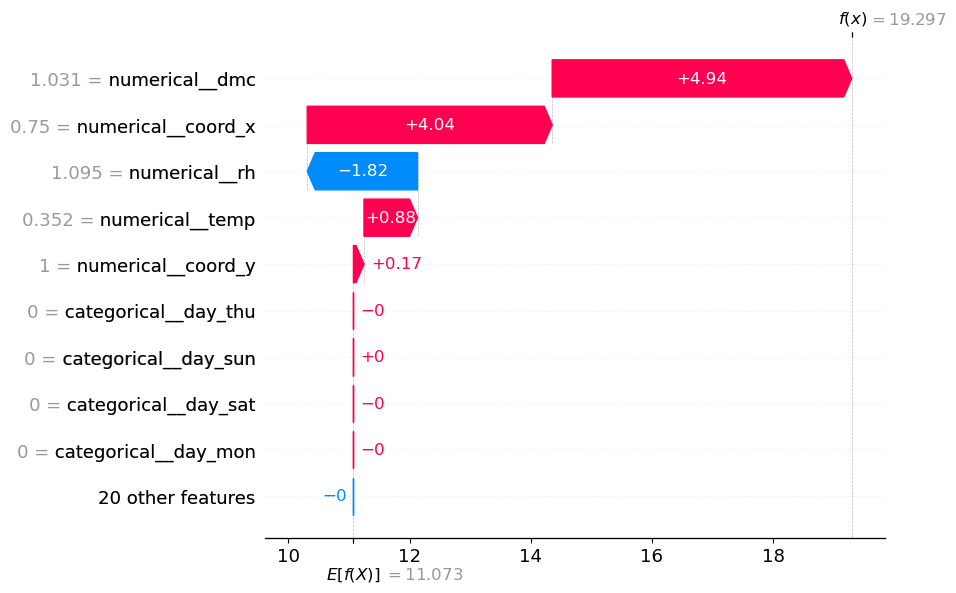

In [175]:
# get data transformation + best model, preprocessing, regressor
data_transform = best_pipe.named_steps['preprocessing'].transform(X_test)
best_model = best_pipe.named_steps['regressor']

# create df of transformed data
best_df = pd.DataFrame(data_transform, columns=best_pipe.named_steps['preprocessing'].get_feature_names_out())
best_df.head()

# create the explainer now
explainer = shap.Explainer(
    best_model,
    data_transform, 
    feature_names = best_pipe.named_steps['preprocessing'].get_feature_names_out()
)

# create the array
shap_result = explainer(data_transform)

# show the waterfall plot
shap.plots.waterfall(shap_result[1])

In the test set here, we notice the most important features are 'dmc', 'coord_x', 'rh', and 'temp'. We know these are the most important as they are ordered among the top of the beeswarm plots.  
'dmc', 'coord_x', and 'temp' seem to positively affect the model output, where 'rh' negatively impacts the output. Knowing outcome is area burned, these variables make sense. Increases in temperature likely contributed to larger forest fires and thus more burned area. Relative humidity means more moisture in the area, and increased moisture likely prevents forest fires. 

In [176]:
# get data transformation + best model, preprocessing, regressor
data_transform = best_pipe.named_steps['preprocessing'].transform(X_train)
best_model = best_pipe.named_steps['regressor']

# create df of transformed data
best_df = pd.DataFrame(data_transform, columns=best_pipe.named_steps['preprocessing'].get_feature_names_out())
best_df.head()


,numerical__coord_x,numerical__coord_y,numerical__ffmc,numerical__dmc,numerical__dc,numerical__isi,numerical__temp,numerical__rh,numerical__wind,numerical__rain,...,categorical__month_nov,categorical__month_oct,categorical__month_sep,categorical__day_fri,categorical__day_mon,categorical__day_sat,categorical__day_sun,categorical__day_thu,categorical__day_tue,categorical__day_wed
0,0.50,-1.0,0.296296,-0.036879,0.331217,0.365854,0.802817,-0.666667,-0.814815,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.50,1.0,-0.148148,-0.200000,0.282892,0.000000,-0.323944,0.238095,0.333333,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.75,0.0,-0.518519,0.035461,-0.447266,-0.536585,0.056338,0.047619,0.666667,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.00,2.0,0.185185,0.626950,-0.021164,1.439024,0.140845,0.761905,0.185185,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.50,1.0,-14.148148,-0.530496,-1.518166,-1.951220,-1.197183,2.285714,-0.481481,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [177]:
# create the explainer now
explainer = shap.Explainer(
    best_model,
    data_transform, 
    feature_names = best_pipe.named_steps['preprocessing'].get_feature_names_out()
)

# create the array
shap_result = explainer(data_transform)

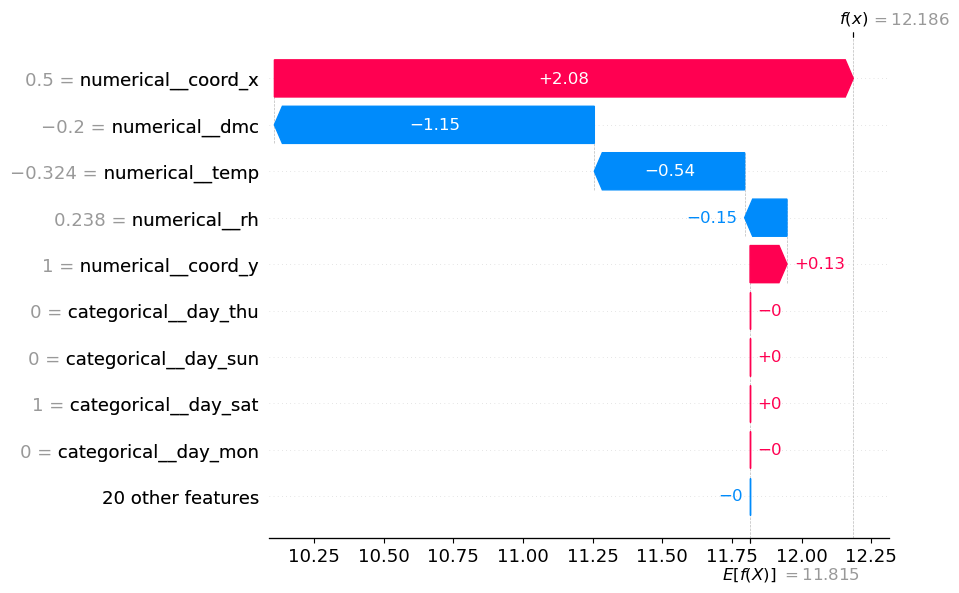

In [178]:
# show the waterfall plot
shap.plots.waterfall(shap_result[1])

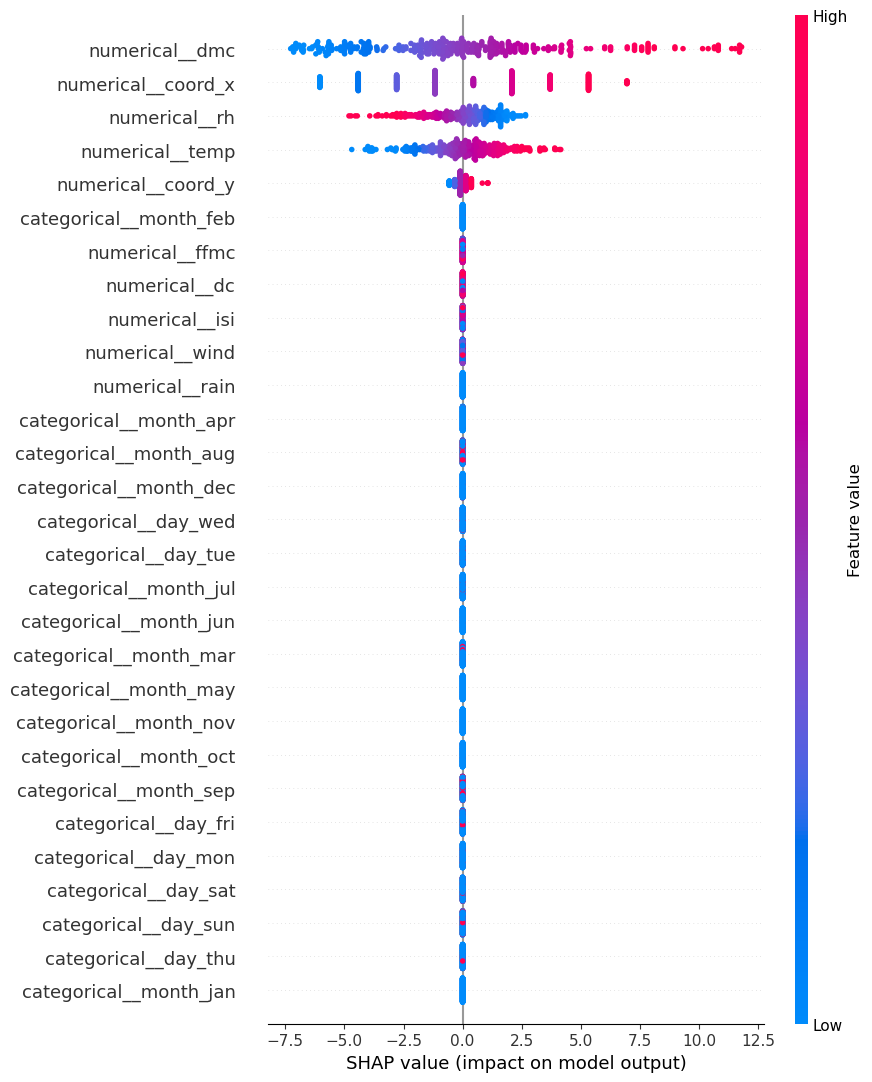

In [179]:
# show the beeswarm plot
shap.plots.beeswarm(shap_result, max_display=30, order=shap_result.abs.max(0))

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In the overall model, we can highly important features include 'dmc', 'coord_x', 'rh', and 'temp'. These variables are at the top of the beeswarm plot and thus represent the highest level of importance. It appears 'dmc', 'coord_x', and 'temp' widely has a postive impact on the models, where increases in these values lead to more area burned by forest fires. 'temp
 appears to have a negative impact on model values, increases in this value prevents areas burned by forest fires.

If I were to remove features from the model, it would be those features among the bottom of the beeswarm plot. This includes features representing days (thu, sun, sat, mon, fri), and months (jan, sep, oct, nov, may, mar, jun). By removing these variables, the hope would be improved fitting of the model. We should see improvements on our scoring metrics like the negative root mean squared error. We could like test whether there was a significant change by using a t-test. In this case, we would take the mean of RMSE of our models, prior to dropping the features, and then compare the RMSE of the models after dropping the features. This should allow us to detect whether a significant change exists. 



## Criteria

The [rubric](./assignment_3_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.